<a href="https://colab.research.google.com/github/aumer1800/Phishinng_Website_ML/blob/main/Phishing_website.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Upload kaggle json file

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle (2).json to kaggle (2) (1).json


#Download dataset directly from kaggle

In [ ]:
# Install Kaggle if needed
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d eswarchandt/phishing-website-detector

Dataset URL: https://www.kaggle.com/datasets/eswarchandt/phishing-website-detector
License(s): unknown
100% 197k/197k [00:00<00:00, 119MB/s]



# Unzip the dataset



In [ ]:
import zipfile

with zipfile.ZipFile("phishing-website-detector.zip", "r") as zip_ref:
    zip_ref.extractall("phishing-website-detector")

#Check the dataset structure

In [ ]:
import os
for root,dirs ,files in os.walk("phishing-website-detector"):
  for file in files:
    print(os.path.join(root , file))

phishing-website-detector/phishing.txt
phishing-website-detector/phishing.csv


# Load the dataset

In [ ]:
import pandas as pd

df = pd.read_csv(
    "phishing-website-detector/phishing.csv",
    encoding="utf-8-sig"
)

# Data Cleaning Steps:

In [ ]:
df.shape

(11054, 32)

In [ ]:
df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [ ]:
df.isnull().sum()

,0
Index,0
UsingIP,0
LongURL,0
ShortURL,0
Symbol@,0
Redirecting//,0
PrefixSuffix-,0
SubDomains,0
HTTPS,0
DomainRegLen,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

In [ ]:
df.describe()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
count,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,...,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000
mean,5526.500000,0.313914,-0.633345,0.738737,0.700561,0.741632,-0.734938,0.064049,0.251040,-0.336711,...,0.613353,0.816899,0.061335,0.377239,0.287407,-0.483626,0.721549,0.343948,0.719739,0.113986
std,3191.159272,0.949495,0.765973,0.674024,0.713625,0.670837,0.678165,0.817492,0.911856,0.941651,...,0.789845,0.576807,0.998162,0.926158,0.827680,0.875314,0.692395,0.569936,0.694276,0.993527
min,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2763.250000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5526.500000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8289.750000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11053.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df = df.drop(columns=['Index'])

#Check Target Distribution

In [ ]:
print(df['class'].value_counts())

class
 1    6157
-1    4897
Name: count, dtype: int64


In [ ]:
print(
    df['class'].value_counts(normalize=True) * 100
)

class
 1    55.699294
-1    44.300706
Name: proportion, dtype: float64


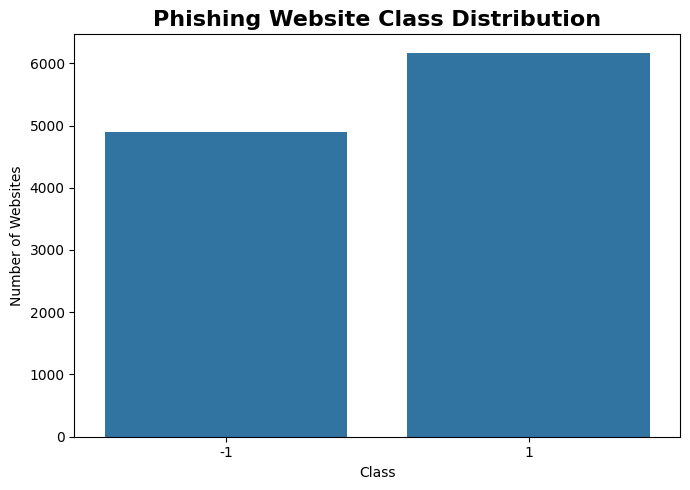

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='class'
)

plt.title(
    'Phishing Website Class Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Class')
plt.ylabel('Number of Websites')

plt.tight_layout()
plt.show()

# Feature Selection

In [ ]:
X = df.drop(columns=['class'])
y = df['class']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11054, 30)
y shape: (11054,)


# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (8843, 30)
Testing : (2211, 30)


# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print("-------------------------")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")
print(f"ROC-AUC  : {roc_auc_lr:.4f}")

Logistic Regression
-------------------------
Accuracy : 0.9389
Precision: 0.9406
Recall   : 0.9505
F1 Score : 0.9455
ROC-AUC  : 0.9824


# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

Model Evaluation

In [ ]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

print("KNN")
print("-------------------------")
print(f"Accuracy : {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"F1 Score : {f1_knn:.4f}")
print(f"ROC-AUC  : {roc_auc_knn:.4f}")

KNN
-------------------------
Accuracy : 0.9412
Precision: 0.9444
Recall   : 0.9505
F1 Score : 0.9474
ROC-AUC  : 0.9846


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

Model Evaluation

In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree")
print("-------------------------")
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")

Decision Tree
-------------------------
Accuracy : 0.9656
Precision: 0.9669
Recall   : 0.9716
F1 Score : 0.9692
ROC-AUC  : 0.9741


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

Model Evaluation

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("-------------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Random Forest
-------------------------
Accuracy : 0.9738
Precision: 0.9688
Recall   : 0.9846
F1 Score : 0.9767
ROC-AUC  : 0.9945


# Model comparisons

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_lr,
        accuracy_knn,
        accuracy_dt,
        accuracy_rf
    ],

    'Precision': [
        precision_lr,
        precision_knn,
        precision_dt,
        precision_rf
    ],

    'Recall': [
        recall_lr,
        recall_knn,
        recall_dt,
        recall_rf
    ],

    'F1 Score': [
        f1_lr,
        f1_knn,
        f1_dt,
        f1_rf
    ],

    'ROC-AUC': [
        roc_auc_lr,
        roc_auc_knn,
        roc_auc_dt,
        roc_auc_rf
    ]
})

results = results.sort_values(
    by='ROC-AUC',
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.973768,0.968850,0.984578,0.976651,0.994479
1,KNN,0.941203,0.944355,0.950487,0.947411,0.984616
2,Logistic Regression,0.938942,0.940562,0.950487,0.945499,0.982430
3,Decision Tree,0.965626,0.966882,0.971591,0.969231,0.974149


# Confusion Matrix for best model

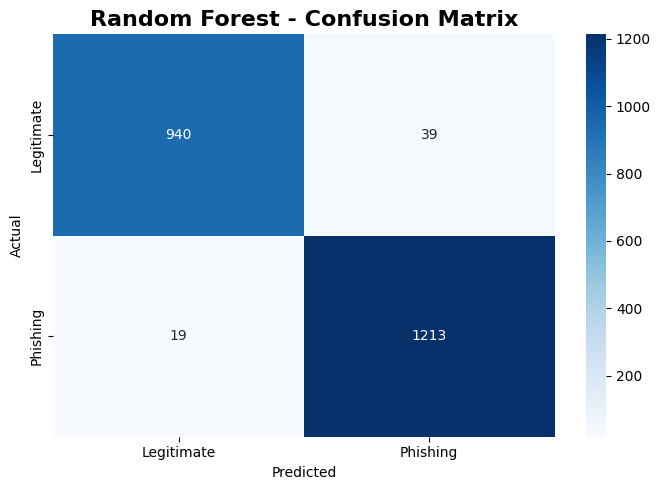

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Phishing'],
    yticklabels=['Legitimate', 'Phishing']
)

plt.title(
    'Random Forest - Confusion Matrix',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC Curve

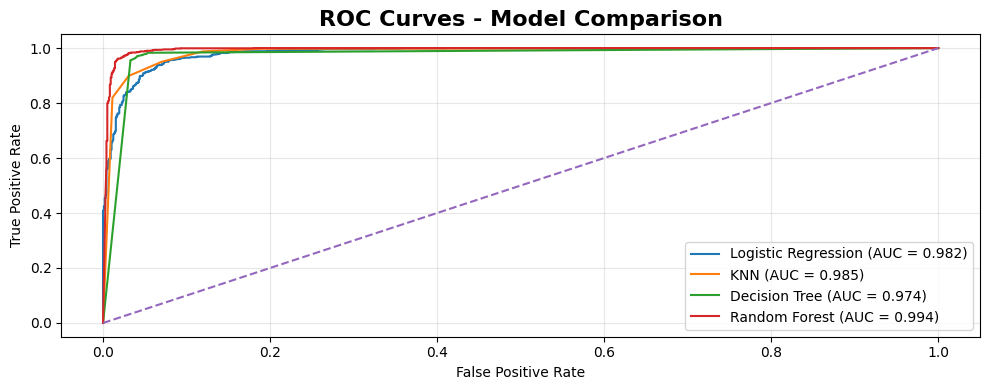

In [ ]:
from sklearn.metrics import roc_curve

models_probabilities = {
    'Logistic Regression': y_prob_lr,
    'KNN': y_prob_knn,
    'Decision Tree': y_prob_dt,
    'Random Forest': y_prob_rf
}

plt.figure(figsize=(10, 4))

for name, probabilities in models_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {auc:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.title(
    'ROC Curves - Model Comparison',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()